In [ ]:
# =====================================================================
# PRÁCTICA: Mi Primera Red Convolucional (CNN) Básica con MNIST
# =====================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Configurar el dispositivo (Usar GPU si está disponible para ir más rápido)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilizando dispositivo: {device}")



Utilizando dispositivo: cuda


In [ ]:
# 2. Descargar y Preparar el Dataset MNIST
# Transformación básica: Convertir las imágenes a Tensores
transform = transforms.ToTensor()

# Descargamos el set de entrenamiento y el de prueba
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Creamos los DataLoaders para manejar la imagen por lotes (Batches de 64 imágenes)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)



In [ ]:
# =====================================================================
# 3. Definición de la Arquitectura CNN Básica
# =====================================================================
class CNNBasica(nn.Module):
    def __init__(self):
        super(CNNBasica, self).__init__()

        # Capa Convolucional: Entrada=1 canal (gris), Salida=16 filtros, Kernel=3x3, Padding=1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        # Capa Max Pooling: Reduce el tamaño a la mitad (de 28x28 a 14x14)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Capa Totalmente Conectada (Linear):
        # Entrada: 16 canales * 14 de alto * 14 de ancho = 3136 características aplanadas
        # Salida: 10 clases (números del 0 al 9)
        self.fc = nn.Linear(16 * 14 * 14, 10)

    def forward(self, x):
        # Flujo de la arquitectura: Convolución -> ReLU -> Pooling
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Aplanar el mapa de características para poder pasarlo a la capa lineal
        x = x.view(x.size(0), -1)

        # Clasificación final
        x = self.fc(x)
        return x

# Instanciar el modelo y pasarlo al dispositivo (CPU/GPU)
model = CNNBasica().to(device)



In [ ]:
# 4. Definir Función de Pérdida (Loss) y Optimitzador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)



In [ ]:
# =====================================================================
# 5. Entrenamiento del Modelo (Solo 2 Épocas para demostración rápida)
# =====================================================================
num_epochs = 60
print("\nIniciando el entrenamiento...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Paso hacia adelante (Forward pass)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Paso hacia atrás y optimización (Backward pass)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i+1) % 300 == 0:
            print(f"Época [{epoch+1}/{num_epochs}], Paso [{i+1}/{len(train_loader)}], Pérdida: {running_loss/300:.4f}")
            running_loss = 0.0

print("¡Entrenamiento finalizado!")




Iniciando el entrenamiento...
Época [1/60], Paso [300/938], Pérdida: 0.3354
Época [1/60], Paso [600/938], Pérdida: 0.1135
Época [1/60], Paso [900/938], Pérdida: 0.0853
Época [2/60], Paso [300/938], Pérdida: 0.0667
Época [2/60], Paso [600/938], Pérdida: 0.0691
Época [2/60], Paso [900/938], Pérdida: 0.0628
Época [3/60], Paso [300/938], Pérdida: 0.0423
Época [3/60], Paso [600/938], Pérdida: 0.0558
Época [3/60], Paso [900/938], Pérdida: 0.0491
Época [4/60], Paso [300/938], Pérdida: 0.0363
Época [4/60], Paso [600/938], Pérdida: 0.0365
Época [4/60], Paso [900/938], Pérdida: 0.0457
Época [5/60], Paso [300/938], Pérdida: 0.0293
Época [5/60], Paso [600/938], Pérdida: 0.0358
Época [5/60], Paso [900/938], Pérdida: 0.0319
Época [6/60], Paso [300/938], Pérdida: 0.0233
Época [6/60], Paso [600/938], Pérdida: 0.0257
Época [6/60], Paso [900/938], Pérdida: 0.0327
Época [7/60], Paso [300/938], Pérdida: 0.0186
Época [7/60], Paso [600/938], Pérdida: 0.0219
Época [7/60], Paso [900/938], Pérdida: 0.0257
Épo

In [ ]:
# =====================================================================
# 6. Evaluación en el Set de Prueba e Inferencia Visual
# =====================================================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'\nExactitud (Accuracy) del modelo en las 10,000 imágenes de prueba: {100 * correct / total:.2f}%')




Exactitud (Accuracy) del modelo en las 10,000 imágenes de prueba: 97.91%


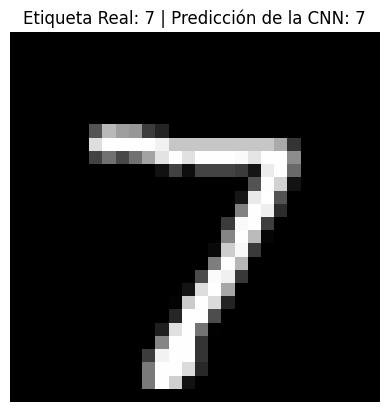

In [ ]:
# 7. Mostrar una predicción en pantalla
imagenes_muestra, etiquetas_muestra = next(iter(test_loader))
con_prediccion = model(imagenes_muestra.to(device))
_, prediccion = torch.max(con_prediccion, 1)

# Dibujar el primer elemento del lote
plt.imshow(imagenes_muestra[0].squeeze(), cmap='gray')
plt.title(f"Etiqueta Real: {etiquetas_muestra[0].item()} | Predicción de la CNN: {prediccion[0].item()}")
plt.axis('off')
plt.show()

## 8. Ingresar un número y que el modelo lo prediga



In [ ]:
# =====================================================================
# 8.1 Función para preprocesar cualquier imagen al formato de MNIST
# =====================================================================
import numpy as np

def preprocesar_imagen_para_modelo(imagen_pil):
    """
    Toma una imagen en cualquier formato (foto, dibujo, captura de pantalla...)
    y la transforma para que quede igual que las imágenes de MNIST con las que
    se entrenó el modelo:

        1. Convertir a escala de grises (1 solo canal).
        2. Redimensionar a 28x28 píxeles (el tamaño que espera la CNN).
        3. Si el fondo es claro (como una hoja blanca), invertir los colores,
           porque MNIST tiene el número en blanco sobre fondo negro.
        4. Normalizar los valores de [0, 255] a [0, 1].
        5. Convertir a tensor y agregar las dimensiones [batch, canal] que
           espera el modelo -> forma final [1, 1, 28, 28].

    Retorna:
        tensor_imagen        -> tensor [1, 1, 28, 28], listo para el modelo
        imagen_para_mostrar  -> arreglo NumPy 28x28, para graficar con imshow
    """
    # 1. Escala de grises
    imagen_gris = imagen_pil.convert('L')

    # 2. Redimensionar a 28x28 (igual que las imágenes de MNIST)
    imagen_gris = imagen_gris.resize((28, 28))

    # Convertimos a arreglo de NumPy para poder revisar y ajustar el fondo
    arreglo = np.array(imagen_gris).astype(np.float32)

    # 3. Si el promedio de brillo es alto, el fondo es claro (número oscuro
    # sobre fondo blanco): es lo contrario de MNIST, así que invertimos.
    if arreglo.mean() > 127:
        arreglo = 255.0 - arreglo

    # 4. Normalizar a [0, 1], igual que hace transforms.ToTensor()
    arreglo = arreglo / 255.0

    # 5. Convertir a tensor y darle la forma [1, 1, 28, 28]
    tensor_imagen = torch.from_numpy(arreglo).float()
    tensor_imagen = tensor_imagen.unsqueeze(0).unsqueeze(0)  # [batch=1, canal=1, 28, 28]

    return tensor_imagen, arreglo


In [ ]:
# =====================================================================
# 8.2 Función para predecir y mostrar el resultado
# =====================================================================

def predecir_numero(imagen_pil, mostrar_probabilidades=True):
    """
    Recibe una imagen (PIL), la preprocesa con la función anterior, la pasa
    por el modelo ya entrenado, y muestra:
      - La imagen tal como la "ve" el modelo (28x28, en gris).
      - El número predicho y la confianza (probabilidad) de esa predicción.
      - Opcionalmente, un gráfico de barras con la probabilidad que el
        modelo le asignó a cada uno de los 10 dígitos posibles.
    """
    tensor_imagen, imagen_28x28 = preprocesar_imagen_para_modelo(imagen_pil)
    tensor_imagen = tensor_imagen.to(device)

    model.eval()
    with torch.no_grad():
        salida = model(tensor_imagen)
        # softmax convierte las salidas "crudas" del modelo en probabilidades
        # que suman 1 entre las 10 clases (0 al 9)
        probabilidades = torch.softmax(salida, dim=1)
        _, prediccion = torch.max(salida, 1)

    numero_predicho = prediccion.item()
    confianza = probabilidades[0][numero_predicho].item() * 100

    if mostrar_probabilidades:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    else:
        fig, ax1 = plt.subplots(figsize=(4, 4))

    # Imagen ya preprocesada (así es como el modelo realmente la recibe)
    ax1.imshow(imagen_28x28, cmap='gray')
    ax1.set_title(f"Predicción: {numero_predicho}\n(Confianza: {confianza:.1f}%)")
    ax1.axis('off')

    if mostrar_probabilidades:
        probabilidades_np = probabilidades[0].cpu().numpy()
        ax2.bar(range(10), probabilidades_np, color='steelblue')
        ax2.set_xticks(range(10))
        ax2.set_xlabel("Dígito")
        ax2.set_ylabel("Probabilidad")
        ax2.set_title("Confianza del modelo por dígito")
        ax2.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    return numero_predicho


### Opción 1:

Sube una foto o captura de un número escrito a mano. Para mejores resultados:
- Que el número se vea claro y con trazos gruesos.
- Que ocupe la mayor parte de la imagen (sin demasiado espacio vacío alrededor).
- Fondo simple (una hoja en blanco funciona bien).

Sube una imagen con un número escrito a mano (0-9)...


Saving numero_3.png to numero_3 (2).png


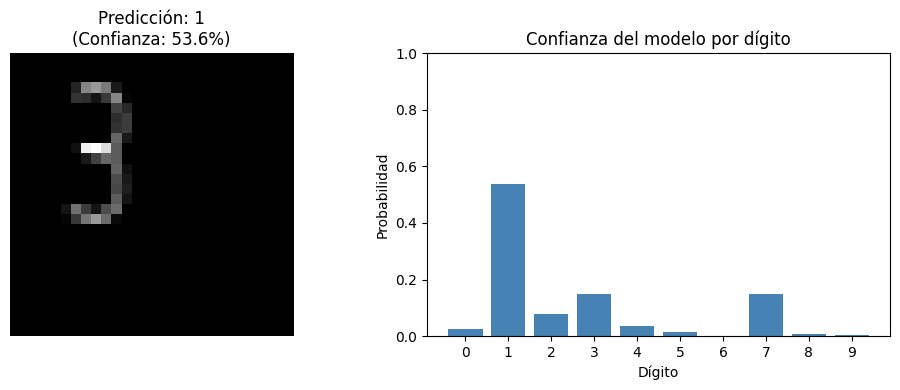

1

In [ ]:
# =====================================================================
# 8.3 Opción 1: Subir una imagen desde tu computadora
# =====================================================================
from google.colab import files
from PIL import Image
import io

print("Sube una imagen con un número escrito a mano (0-9)...")
archivos_subidos = files.upload()

# Tomamos el primer archivo subido (si subes varios, solo se usa el primero)
nombre_archivo = list(archivos_subidos.keys())[0]
imagen_subida = Image.open(io.BytesIO(archivos_subidos[nombre_archivo]))

predecir_numero(imagen_subida)


### Opción 2 (extra): Dibujar el número directamente en Colab


<IPython.core.display.Javascript object>

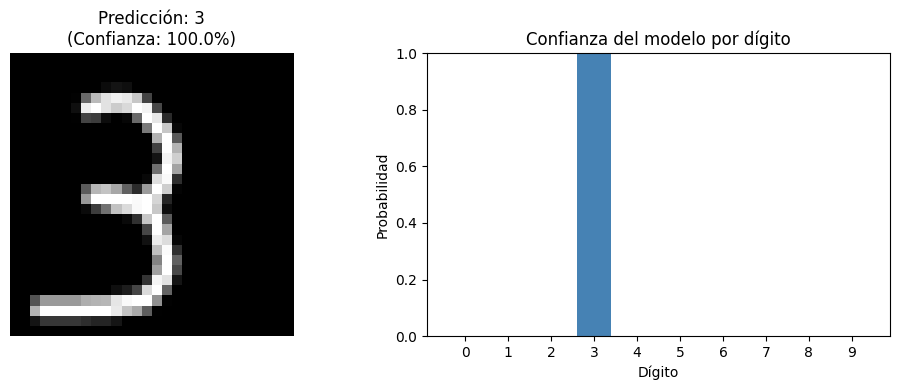

3

In [ ]:
# =====================================================================
# 8.4 Opción 2 (extra): Dibujar el número en un lienzo dentro de Colab
# =====================================================================
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode


def dibujar_numero():
    """
    Muestra un lienzo (canvas) en el navegador donde puedes dibujar un número
    con el mouse. Al presionar "Predecir", el dibujo se envía de vuelta a
    Python como una imagen codificada en base64 (texto), que luego
    decodificamos y convertimos en una imagen de PIL normal -para poder
    usarla con la misma función 'predecir_numero' de la Opción 1.
    """
    codigo_js = """
    async function dibujarNumero() {
        const canvas = document.createElement('canvas');
        canvas.width = 280;
        canvas.height = 280;
        canvas.style.border = '2px solid black';
        canvas.style.cursor = 'crosshair';

        const ctx = canvas.getContext('2d');
        ctx.fillStyle = 'black';
        ctx.fillRect(0, 0, canvas.width, canvas.height);
        ctx.strokeStyle = 'white';
        ctx.lineWidth = 18;
        ctx.lineCap = 'round';
        ctx.lineJoin = 'round';

        let dibujando = false;
        let ultimoX = 0, ultimoY = 0;

        function obtenerPos(evento) {
            const rect = canvas.getBoundingClientRect();
            return [evento.clientX - rect.left, evento.clientY - rect.top];
        }

        canvas.addEventListener('mousedown', (e) => {
            dibujando = true;
            [ultimoX, ultimoY] = obtenerPos(e);
        });
        canvas.addEventListener('mousemove', (e) => {
            if (!dibujando) return;
            const [x, y] = obtenerPos(e);
            ctx.beginPath();
            ctx.moveTo(ultimoX, ultimoY);
            ctx.lineTo(x, y);
            ctx.stroke();
            [ultimoX, ultimoY] = [x, y];
        });
        canvas.addEventListener('mouseup', () => dibujando = false);
        canvas.addEventListener('mouseleave', () => dibujando = false);

        const botonBorrar = document.createElement('button');
        botonBorrar.textContent = 'Borrar';
        botonBorrar.onclick = () => {
            ctx.fillStyle = 'black';
            ctx.fillRect(0, 0, canvas.width, canvas.height);
        };

        const botonPredecir = document.createElement('button');
        botonPredecir.textContent = 'Predecir';
        botonPredecir.style.marginLeft = '10px';

        document.body.appendChild(canvas);
        document.body.appendChild(document.createElement('br'));
        document.body.appendChild(botonBorrar);
        document.body.appendChild(botonPredecir);

        return new Promise((resolve) => {
            botonPredecir.onclick = () => {
                resolve(canvas.toDataURL('image/png'));
            };
        });
    }
    """
    display(Javascript(codigo_js))
    datos_imagen = eval_js("dibujarNumero()")
    encabezado, datos_codificados = datos_imagen.split(',', 1)
    bytes_imagen = b64decode(datos_codificados)
    return Image.open(io.BytesIO(bytes_imagen))


# Dibuja tu número en el lienzo que aparece abajo y presiona "Predecir"
imagen_dibujada = dibujar_numero()
predecir_numero(imagen_dibujada)
